In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import json
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [3]:
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")

data_path = "C:\\Users\\danak\\Downloads\\1_Intro_Color_models\\Curs\\EuroSAT"

train_df = pd.read_csv(os.path.join(data_path, "train.csv"))
val_df = pd.read_csv(os.path.join(data_path, "validation.csv"))
test_df = pd.read_csv(os.path.join(data_path, "test.csv"))

with open(os.path.join(data_path, "label_map.json"), 'r') as f:
    label_map = json.load(f)

print("Структура данных:")
print(f"Обучающая выборка: {len(train_df)} изображений")
print(f"Валидационная выборка: {len(val_df)} изображений")
print(f"Тестовая выборка: {len(test_df)} изображений")
print("Классы:", label_map)

Структура данных:
Обучающая выборка: 18900 изображений
Валидационная выборка: 5400 изображений
Тестовая выборка: 2700 изображений
Классы: {'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


АНАЛИЗ БАЛАНСИРОВКИ ПО КЛАССАМ:


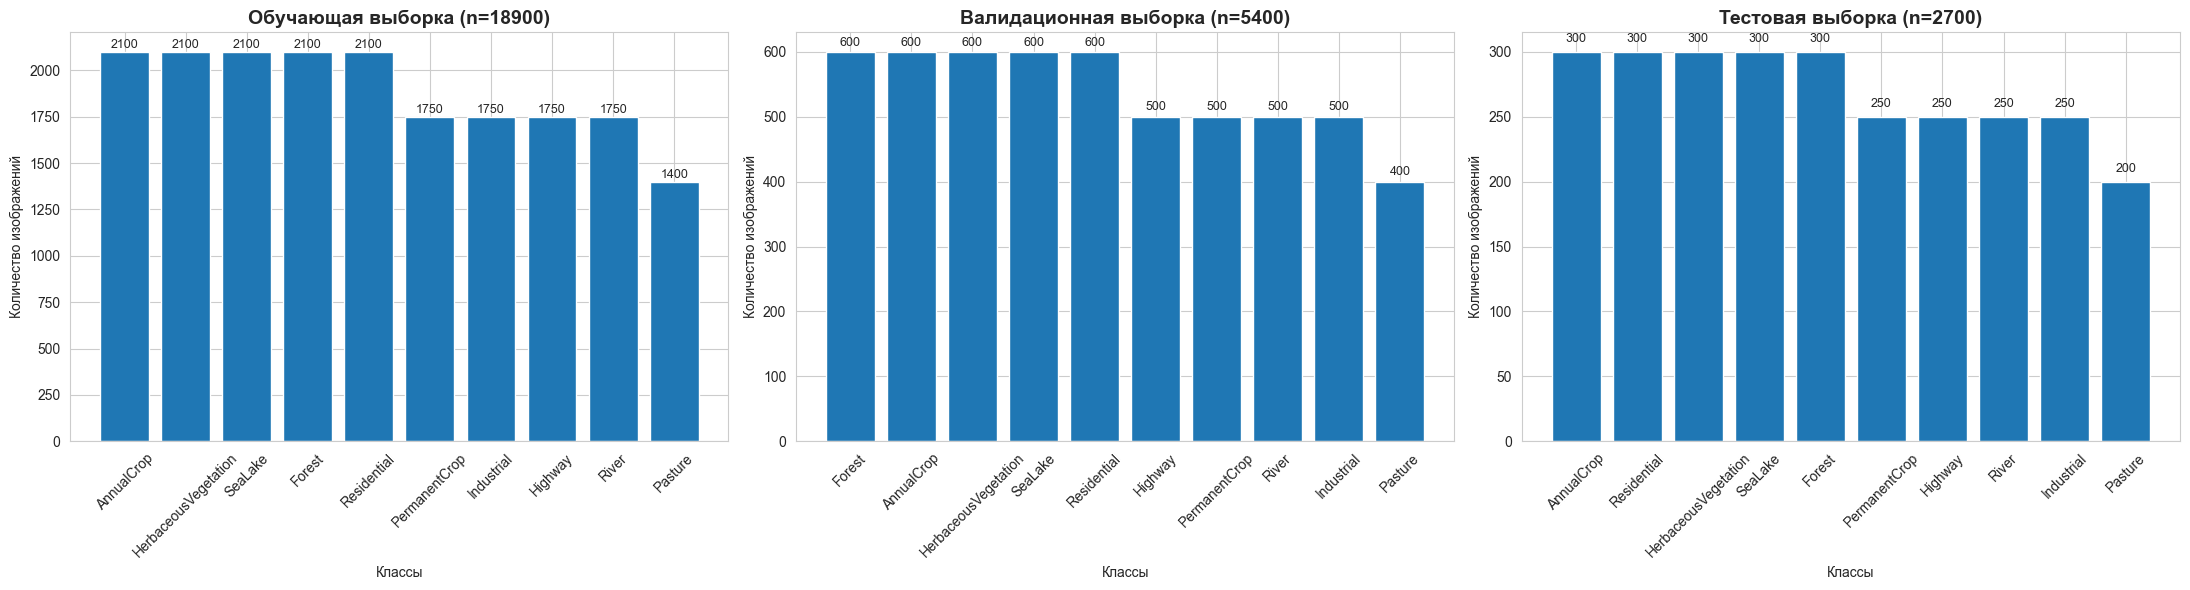

== Обучающая выборка: ==
Всего изображений: 18900
Количество классов: 10
Минимальное количество в классе: 1400
Максимальное количество в классе: 2100
Среднее количество: 1890.0
Стандартное отклонение: 244.7
Коэффициент вариации (показатель неравномерности): 12.9%
Выборка ХОРОШО сбалансирована

== Валидационная выборка: ==
Всего изображений: 5400
Количество классов: 10
Минимальное количество в классе: 400
Максимальное количество в классе: 600
Среднее количество: 540.0
Стандартное отклонение: 69.9
Коэффициент вариации (показатель неравномерности): 12.9%
Выборка ХОРОШО сбалансирована

== Тестовая выборка: ==
Всего изображений: 2700
Количество классов: 10
Минимальное количество в классе: 200
Максимальное количество в классе: 300
Среднее количество: 270.0
Стандартное отклонение: 35.0
Коэффициент вариации (показатель неравномерности): 12.9%
Выборка ХОРОШО сбалансирована



In [4]:
print("АНАЛИЗ БАЛАНСИРОВКИ ПО КЛАССАМ:")
print("=" * 50)

def plot_class_distribution_correct(df, title, ax):
    class_counts = df['ClassName'].value_counts()
    
    bars = ax.bar(class_counts.index, class_counts.values)
    ax.set_title(f'{title} (n={len(df)})', fontsize=14, fontweight='bold')
    ax.set_xlabel('Классы')
    ax.set_ylabel('Количество изображений')
    ax.tick_params(axis='x', rotation=45)
    
    for bar, count in zip(bars, class_counts.values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 5,
                f'{count}', ha='center', va='bottom', fontsize=9)
    
    return class_counts

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))

train_counts = plot_class_distribution_correct(train_df, 'Обучающая выборка', ax1)
val_counts = plot_class_distribution_correct(val_df, 'Валидационная выборка', ax2)
test_counts = plot_class_distribution_correct(test_df, 'Тестовая выборка', ax3)

plt.tight_layout()
plt.show()

for df_name, df, counts in [("Обучающая", train_df, train_counts), 
                           ("Валидационная", val_df, val_counts),
                           ("Тестовая", test_df, test_counts)]:
    
    print(f"== {df_name} выборка: ==")
    print(f"Всего изображений: {len(df)}")
    print(f"Количество классов: {len(counts)}")
    print(f"Минимальное количество в классе: {counts.min()}")
    print(f"Максимальное количество в классе: {counts.max()}")
    print(f"Среднее количество: {counts.mean():.1f}")
    print(f"Стандартное отклонение: {counts.std():.1f}")
    
    cv = (counts.std() / counts.mean()) * 100
    print(f"Коэффициент вариации (показатель неравномерности): {cv:.1f}%")
    
    if cv < 10:
        print("Выборка ОТЛИЧНО сбалансирована\n")
    elif cv < 20:
        print("Выборка ХОРОШО сбалансирована\n")
    elif cv < 30:
        print("Выборка УМЕРЕННО сбалансирована\n")
    else:
        print("Выборка НЕСБАЛАНСИРОВАНА")

In [5]:
print("ДЕТАЛЬНОЕ РАСПРЕДЕЛЕНИЕ ПО КЛАССАМ:")
print("=" * 80)

distribution_summary = pd.DataFrame({
    'Обучающая': train_counts,
    'Валидационная': val_counts,
    'Тестовая': test_counts,
    'Всего': train_counts + val_counts + test_counts
})

distribution_summary['% от общего'] = (distribution_summary['Всего'] / distribution_summary['Всего'].sum() * 100).round(1)
print(distribution_summary)

ДЕТАЛЬНОЕ РАСПРЕДЕЛЕНИЕ ПО КЛАССАМ:
                      Обучающая  Валидационная  Тестовая  Всего  % от общего
ClassName                                                                   
AnnualCrop                 2100            600       300   3000         11.1
Forest                     2100            600       300   3000         11.1
HerbaceousVegetation       2100            600       300   3000         11.1
Highway                    1750            500       250   2500          9.3
Industrial                 1750            500       250   2500          9.3
Pasture                    1400            400       200   2000          7.4
PermanentCrop              1750            500       250   2500          9.3
Residential                2100            600       300   3000         11.1
River                      1750            500       250   2500          9.3
SeaLake                    2100            600       300   3000         11.1


In [6]:
print("ПРОВЕРКА НА ПРОПУСКИ И БИТЫЕ ФАЙЛЫ:")
print("="*37)

def check_files_fixed(df, data_path, dataset_name):
    print(f"{dataset_name}")
    
    missing_files = []
    corrupted_files = []
    valid_files = 0
    image_sizes = []
    
    for idx, row in df.iterrows():
        img_filename = row['Filename']
        
        possible_paths = [
            os.path.join(data_path, img_filename),
            os.path.join(data_path, '..', img_filename),
            img_filename
        ]
        
        img_path = None
        for path in possible_paths:
            if os.path.exists(path):
                img_path = path
                break
        
        if img_path is None:
            missing_files.append(img_filename)
            continue
        
        try:
            with Image.open(img_path) as img:
                img.verify()
            
            with Image.open(img_path) as img:
                img_array = np.array(img)
                if img_array.size == 0:
                    corrupted_files.append(img_filename)
                else:
                    valid_files += 1
                    image_sizes.append(img.size)
                    
        except Exception as e:
            corrupted_files.append(img_filename)
    
    print(f"  Всего файлов в датафрейме: {len(df)}")
    print(f"  Валидных файлов: {valid_files} ({valid_files/len(df)*100:.1f}%)")
    print(f"  Пропущенных файлов: {len(missing_files)}")
    print(f"  Битых файлов: {len(corrupted_files)}\n")
    
    if missing_files:
        print(f"  Примеры пропущенных файлов (первые 3):")
        for f in missing_files[:3]:
            print(f"    - {f}")
    
    return {
        'missing': missing_files,
        'corrupted': corrupted_files,
        'valid': valid_files,
        'sizes': image_sizes
    }

train_check = check_files_fixed(train_df, data_path, "ОБУЧАЮЩАЯ ВЫБОРКА")
val_check = check_files_fixed(val_df, data_path, "ВАЛИДАЦИОННАЯ ВЫБОРКА")
test_check = check_files_fixed(test_df, data_path, "ТЕСТОВАЯ ВЫБОРКА")

ПРОВЕРКА НА ПРОПУСКИ И БИТЫЕ ФАЙЛЫ:
ОБУЧАЮЩАЯ ВЫБОРКА
  Всего файлов в датафрейме: 18900
  Валидных файлов: 18900 (100.0%)
  Пропущенных файлов: 0
  Битых файлов: 0

ВАЛИДАЦИОННАЯ ВЫБОРКА
  Всего файлов в датафрейме: 5400
  Валидных файлов: 5400 (100.0%)
  Пропущенных файлов: 0
  Битых файлов: 0

ТЕСТОВАЯ ВЫБОРКА
  Всего файлов в датафрейме: 2700
  Валидных файлов: 2700 (100.0%)
  Пропущенных файлов: 0
  Битых файлов: 0



In [7]:
print("АНАЛИЗ РАЗМЕРОВ ИЗОБРАЖЕНИЙ:")
print("="*41)

all_sizes = train_check['sizes'] + val_check['sizes'] + test_check['sizes']

if all_sizes:
    sizes_array = np.array(all_sizes)
    widths = sizes_array[:, 0]
    heights = sizes_array[:, 1]
    
    print(f"Проанализировано размеров: {len(all_sizes)}")
    print(f"Уникальные размеры: {len(set(all_sizes))}")

    from collections import Counter
    size_counter = Counter(all_sizes)
    most_common_size, most_common_count = size_counter.most_common(1)[0]
    
    print(f"Самый частый размер: {most_common_size}")
    print(f"Это {most_common_count/len(all_sizes)*100:.1f}% от всех изображений")
    
    unique_sizes = len(set(all_sizes))
    if unique_sizes == 1:
        print("\nВСЕ изображения имеют одинаковый размер!")
    else:
        print("\nИзображения имеют разные размеры")
        print("Наиболее распространенные размеры:")
        for size, count in size_counter.most_common(5):
            print(f"  {size}: {count} изображений ({count/len(all_sizes)*100:.1f}%)")

АНАЛИЗ РАЗМЕРОВ ИЗОБРАЖЕНИЙ:
Проанализировано размеров: 27000
Уникальные размеры: 1
Самый частый размер: (64, 64)
Это 100.0% от всех изображений

ВСЕ изображения имеют одинаковый размер!


ВИЗУАЛИЗАЦИЯ ПРИМЕРОВ ИЗ КАЖДОГО КЛАССА:
Примеры изображений из каждого класса (обучающая выборка):


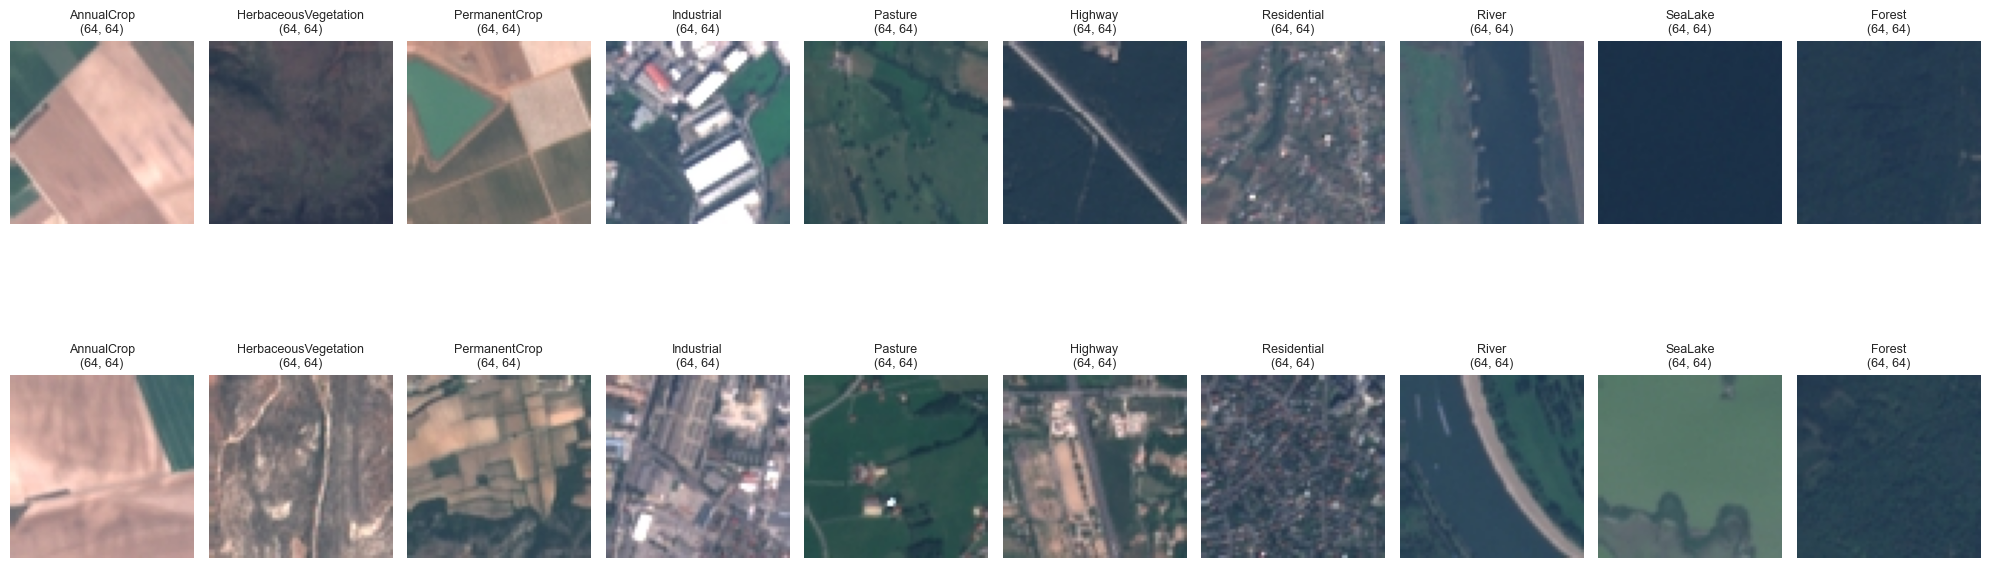

In [8]:
print("ВИЗУАЛИЗАЦИЯ ПРИМЕРОВ ИЗ КАЖДОГО КЛАССА:")
print("="*50)

def display_sample_images_correct(df, data_path, samples_per_class=2):
    classes = df['ClassName'].unique()
    n_classes = len(classes)
    
    fig, axes = plt.subplots(samples_per_class, n_classes, figsize=(20, 4 * samples_per_class))
    
    if samples_per_class == 1:
        axes = axes.reshape(1, -1)
    
    for class_idx, class_name in enumerate(classes):
        class_samples = df[df['ClassName'] == class_name].head(samples_per_class)
        
        for sample_idx in range(samples_per_class):
            if sample_idx < len(class_samples):
                row = class_samples.iloc[sample_idx]
                img_filename = row['Filename']
                
                img_path = None
                possible_paths = [
                    os.path.join(data_path, img_filename),
                    os.path.join(data_path, '..', img_filename),
                    img_filename
                ]
                
                for path in possible_paths:
                    if os.path.exists(path):
                        img_path = path
                        break
                
                if img_path:
                    try:
                        img = Image.open(img_path)
                        ax = axes[sample_idx, class_idx]
                        ax.imshow(img)
                        ax.set_title(f"{class_name}\n{img.size}", fontsize=9)
                        ax.axis('off')
                    except Exception as e:
                        ax = axes[sample_idx, class_idx]
                        ax.text(0.5, 0.5, f'Ошибка\nзагрузки', 
                               ha='center', va='center', transform=ax.transAxes, fontsize=8)
                        ax.set_title(class_name, fontsize=9)
                        ax.axis('off')
                else:
                    ax = axes[sample_idx, class_idx]
                    ax.text(0.5, 0.5, 'Файл\nне найден', 
                           ha='center', va='center', transform=ax.transAxes, fontsize=8)
                    ax.set_title(class_name, fontsize=9)
                    ax.axis('off')
            else:
                axes[sample_idx, class_idx].axis('off')
    
    plt.tight_layout()
    plt.show()

print("Примеры изображений из каждого класса (обучающая выборка):")
display_sample_images_correct(train_df, data_path, samples_per_class=2)